# Regresión lineal — PM2.5 en Albuquerque, Nuevo México (2023)

Este notebook conserva la estructura y el repertorio de código del notebook de referencia **RegresionLineal.ipynb**.

- **Año:** 2023
- **Componente:** PM2.5
- **Lugar:** Albuquerque, Nuevo México
- **Variable objetivo:** `Daily Mean PM2.5 Concentration`


# Importamos librerias

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importamos conjunto de datos

In [10]:
df1 = pd.read_csv("ad_viz_plotval_data.csv")
df1.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,350010023,1,10.3,ug/m3 LC,53,DEL NORTE HIGH SCHOOL,1,100.0,...,238,Teledyne T640X at 16.67 LPM,10740,"Albuquerque, NM",35,New Mexico,1,Bernalillo,35.1343,-106.5852
1,01/02/2023,AQS,350010023,1,1.7,ug/m3 LC,9,DEL NORTE HIGH SCHOOL,1,100.0,...,238,Teledyne T640X at 16.67 LPM,10740,"Albuquerque, NM",35,New Mexico,1,Bernalillo,35.1343,-106.5852
2,01/03/2023,AQS,350010023,1,3.3,ug/m3 LC,18,DEL NORTE HIGH SCHOOL,1,100.0,...,238,Teledyne T640X at 16.67 LPM,10740,"Albuquerque, NM",35,New Mexico,1,Bernalillo,35.1343,-106.5852
3,01/04/2023,AQS,350010023,1,2.8,ug/m3 LC,16,DEL NORTE HIGH SCHOOL,1,100.0,...,238,Teledyne T640X at 16.67 LPM,10740,"Albuquerque, NM",35,New Mexico,1,Bernalillo,35.1343,-106.5852
4,01/05/2023,AQS,350010023,1,7.4,ug/m3 LC,41,DEL NORTE HIGH SCHOOL,1,100.0,...,238,Teledyne T640X at 16.67 LPM,10740,"Albuquerque, NM",35,New Mexico,1,Bernalillo,35.1343,-106.5852


Para seguir la estructura del notebook de referencia se seleccionan cuatro variables predictoras numéricas y la concentración media diaria de PM2.5 como variable objetivo.

In [11]:
column_list = ['Daily AQI Value', 'Site ID', 'Site Latitude', 'Site Longitude', 'Daily Mean PM2.5 Concentration']
df1 = df1[column_list]
df1.head()

,Daily AQI Value,Site ID,Site Latitude,Site Longitude,Daily Mean PM2.5 Concentration
0,53,350010023,35.1343,-106.5852,10.3
1,9,350010023,35.1343,-106.5852,1.7
2,18,350010023,35.1343,-106.5852,3.3
3,16,350010023,35.1343,-106.5852,2.8
4,41,350010023,35.1343,-106.5852,7.4


In [12]:
df1.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3804 entries, 0 to 3803
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Daily AQI Value                 3804 non-null   int64  
 1   Site ID                         3804 non-null   int64  
 2   Site Latitude                   3804 non-null   float64
 3   Site Longitude                  3804 non-null   float64
 4   Daily Mean PM2.5 Concentration  3804 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 148.7 KB


In [13]:
df1.describe().round(1)

,Daily AQI Value,Site ID,Site Latitude,Site Longitude,Daily Mean PM2.5 Concentration
count,3804.0,3804.0,3804.0,3804.0,3804.0
mean,31.4,350010566.9,35.1,-106.6,6.0
std,14.9,712.9,0.1,0.0,3.7
min,0.0,350010023.0,35.0,-106.7,0.0
25%,21.0,350010026.0,35.1,-106.6,3.7
50%,28.0,350010029.0,35.1,-106.6,5.0
75%,40.0,350011013.0,35.2,-106.6,7.2
max,123.0,350012022.0,35.2,-106.5,44.3


In [14]:
df1.columns

Index(['Daily AQI Value', 'Site ID', 'Site Latitude', 'Site Longitude',
       'Daily Mean PM2.5 Concentration'],
      dtype='object')

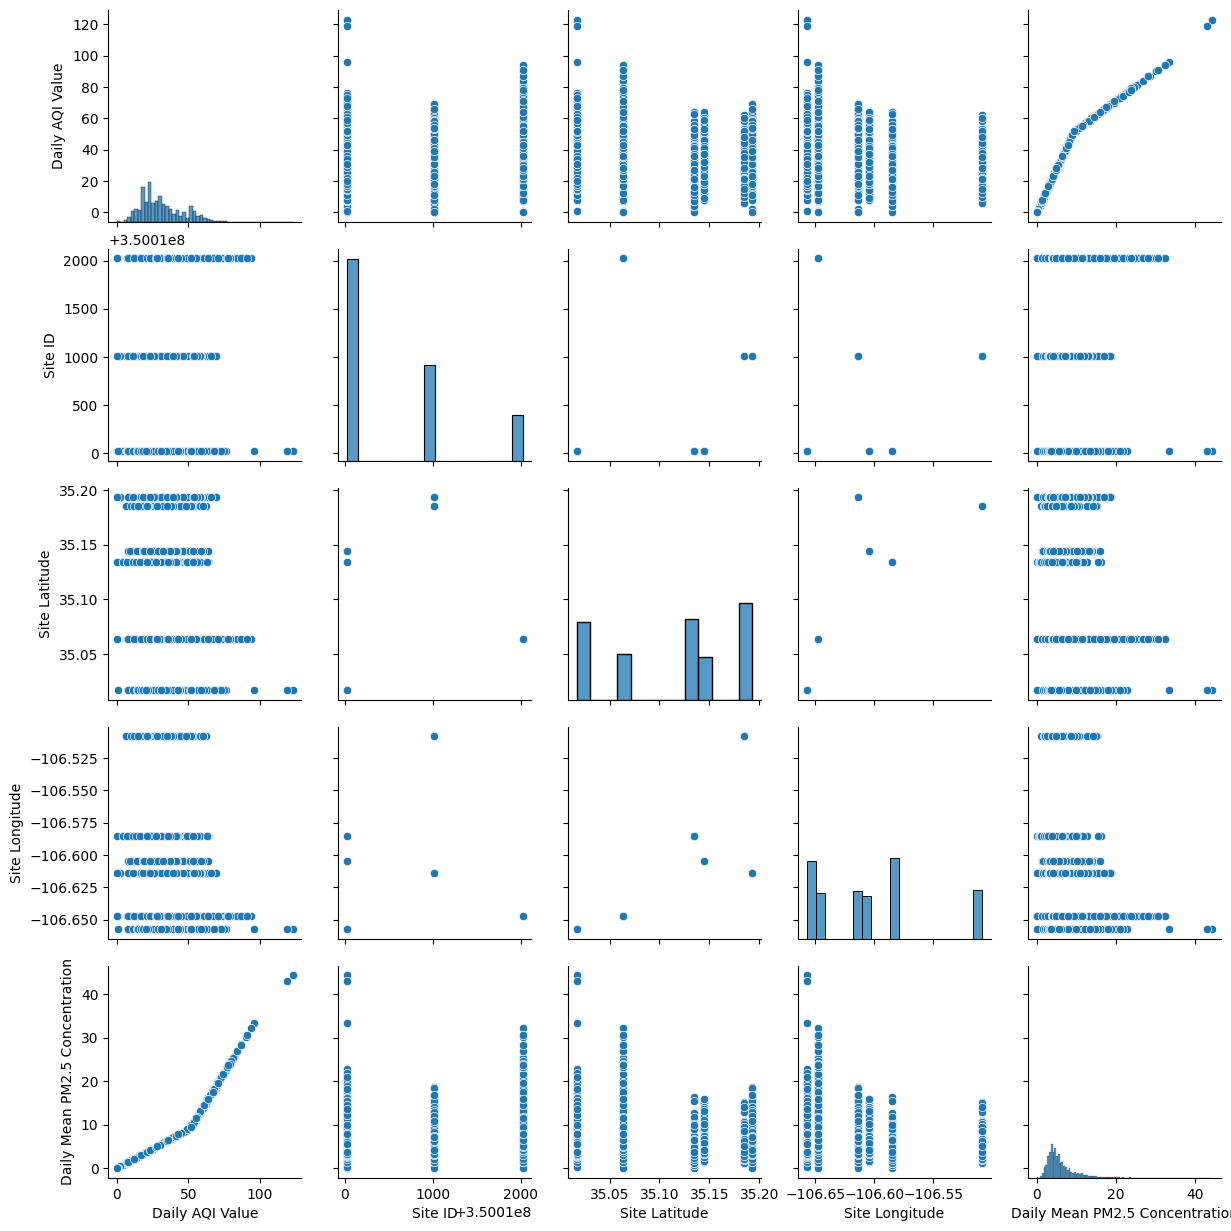

In [15]:
sns.pairplot(df1)
plt.show()

# Exploración gráfica

<Axes: ylabel='Frequency'>

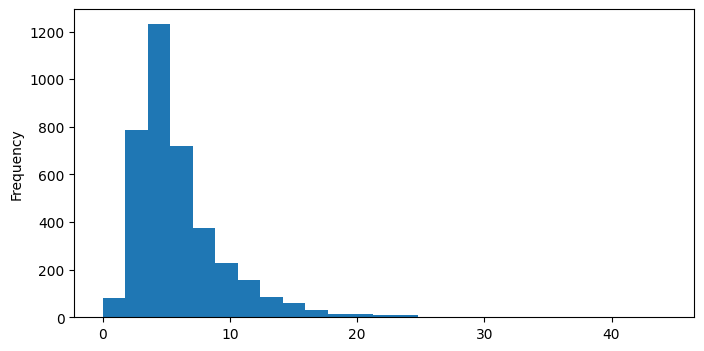

In [16]:
df1['Daily Mean PM2.5 Concentration'].plot.hist(bins=25, figsize=(8,4))

<Axes: ylabel='Density'>

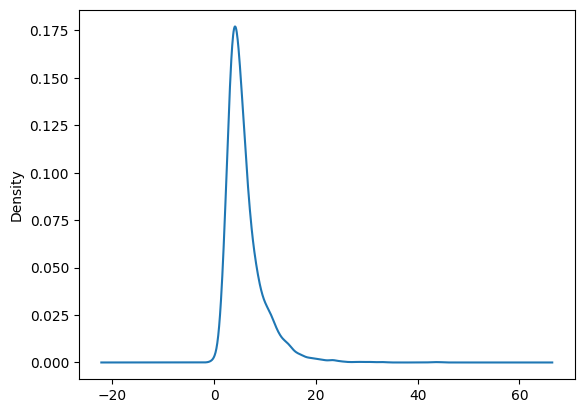

In [17]:
df1['Daily Mean PM2.5 Concentration'].plot.density()

# Correlación

In [18]:
numeric_df1 = df1.select_dtypes(include=[np.number])

numeric_df1.corr().round(4)

,Daily AQI Value,Site ID,Site Latitude,Site Longitude,Daily Mean PM2.5 Concentration
Daily AQI Value,1.0000,0.0885,-0.2821,-0.3774,0.9582
Site ID,0.0885,1.0000,0.1463,0.0351,0.1182
Site Latitude,-0.2821,0.1463,1.0000,0.7711,-0.2697
Site Longitude,-0.3774,0.0351,0.7711,1.0000,-0.3448
Daily Mean PM2.5 Concentration,0.9582,0.1182,-0.2697,-0.3448,1.0000


<Axes: >

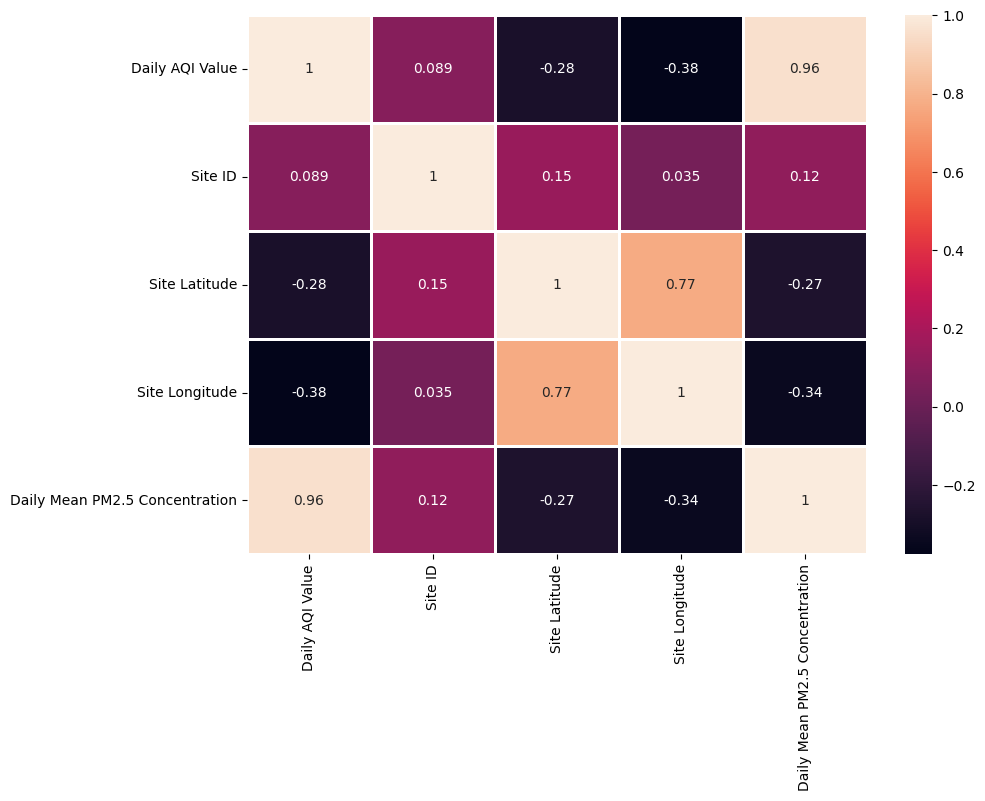

In [19]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df1.corr(), annot=True, linewidths=2)

# Preparación de variables

In [20]:
column_list = list(df1.columns)
len_feature = len(column_list)
column_list

['Daily AQI Value',
 'Site ID',
 'Site Latitude',
 'Site Longitude',
 'Daily Mean PM2.5 Concentration']

In [21]:
x = df1[column_list[0:len_feature-1]]
y = df1[column_list[len_feature-1]]
x.head()

,Daily AQI Value,Site ID,Site Latitude,Site Longitude
0,53,350010023,35.1343,-106.5852
1,9,350010023,35.1343,-106.5852
2,18,350010023,35.1343,-106.5852
3,16,350010023,35.1343,-106.5852
4,41,350010023,35.1343,-106.5852


# División de datos y modelo de regresión lineal

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [25]:
lm = LinearRegression()

In [26]:
lm.fit(X_train,y_train)

LinearRegression()

In [27]:
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: -71568.68133699363


In [28]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [ 2.44259709e-01  2.05912609e-04 -2.26324061e+00  3.98729158e+00]


In [29]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
Daily AQI Value,0.244260
Site ID,0.000206
Site Latitude,-2.263241
Site Longitude,3.987292


# Error estándar y estadístico t

In [30]:
n=X_train.shape[0]
k=X_train.shape[1]
dfN = n-k
train_pred=lm.predict(X_train)
train_error = np.square(train_pred - y_train)
sum_error=np.sum(train_error)
se=[0] * len(X_train.columns)
for i in range(k):
    r = (sum_error/dfN)
    r = r/np.sum(np.square(X_train[list(X_train.columns)[i]]-X_train[list(X_train.columns)[i]].mean()))
    se[i]=np.sqrt(r)
cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coefficients']/cdf['Standard Error']
cdf

,Coefficients,Standard Error,t-statistic
Daily AQI Value,0.244260,0.001431,170.683794
Site ID,0.000206,0.000030,6.814017
Site Latitude,-2.263241,0.331810,-6.820885
Site Longitude,3.987292,0.450079,8.859084


# Variables predictoras vs. PM2.5

Text(0.5, 1.0, 'Site Longitude vs. PM2.5')

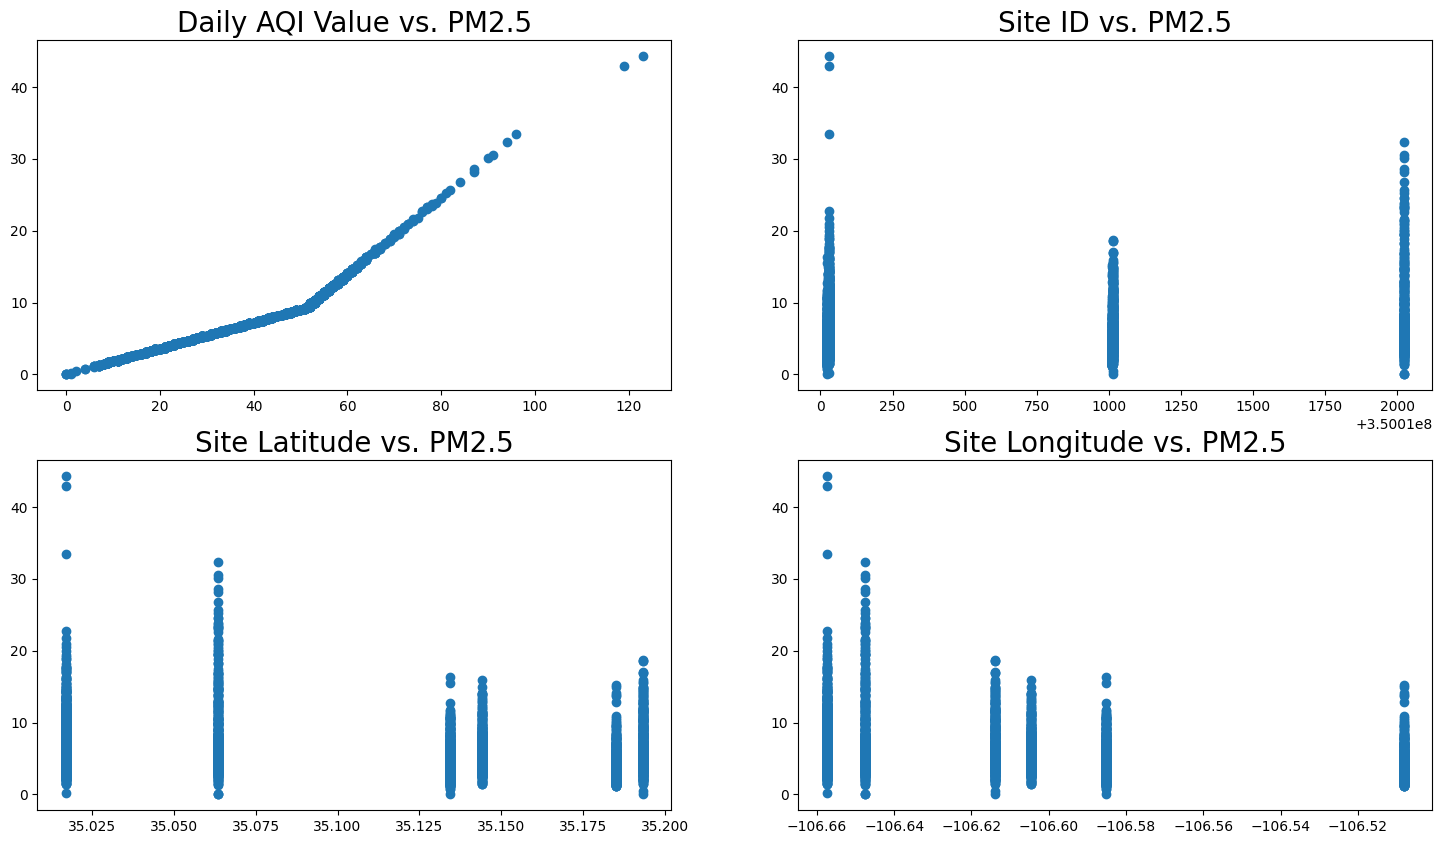

In [31]:
l = list(cdf.index)

from matplotlib import gridspec

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df1[l[0]], df1['Daily Mean PM2.5 Concentration'])
ax0.set_title(l[0] + " vs. PM2.5", fontdict={'fontsize': 20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df1[l[1]], df1['Daily Mean PM2.5 Concentration'])
ax1.set_title(l[1] + " vs. PM2.5", fontdict={'fontsize': 20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df1[l[2]], df1['Daily Mean PM2.5 Concentration'])
ax2.set_title(l[2] + " vs. PM2.5", fontdict={'fontsize': 20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df1[l[3]], df1['Daily Mean PM2.5 Concentration'])
ax3.set_title(l[3] + " vs. PM2.5", fontdict={'fontsize': 20})

# Predicción

In [32]:
predictions = lm.predict(X_test)
print ("Tipo del objeto predicho :", type(predictions))
print ("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (1142,)


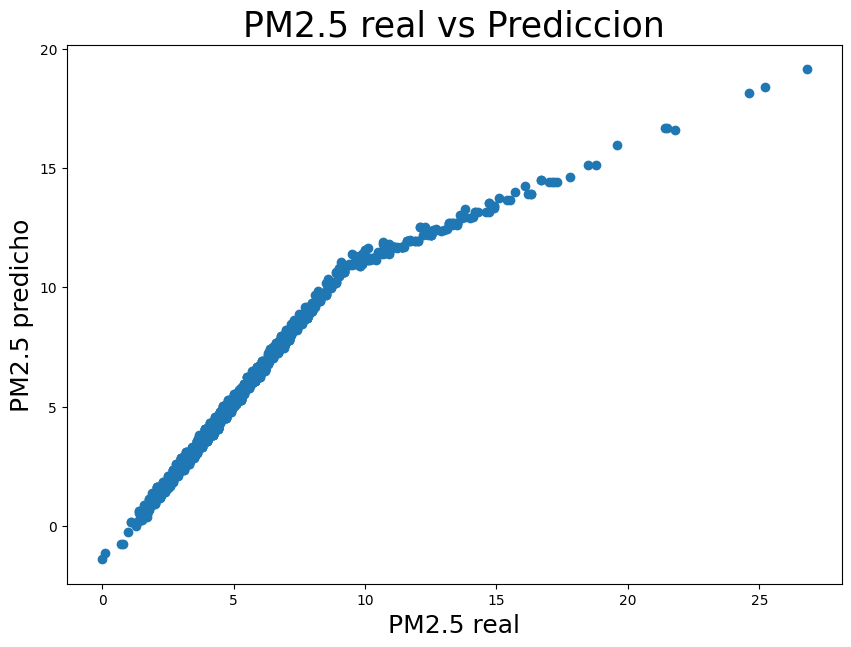

In [33]:
plt.figure(figsize=(10,7))
plt.title("PM2.5 real vs Prediccion",fontsize=25)
plt.xlabel("PM2.5 real",fontsize=18)
plt.ylabel("PM2.5 predicho", fontsize=18)
plt.scatter(x=y_test,y=predictions)

/tmp/ipykernel_2547/648314444.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-predictions)


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad '}, xlabel='Daily Mean PM2.5 Concentration', ylabel='Densidad del kernel'>

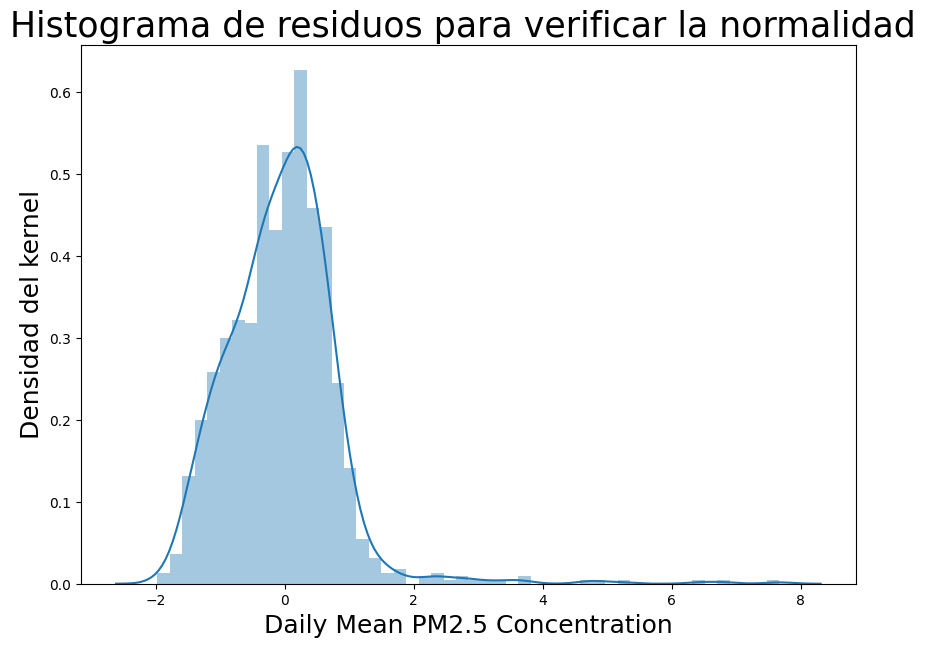

In [34]:
plt.figure(figsize=(10,7))
plt.title("Histograma de residuos para verificar la normalidad ",fontsize=25)
plt.xlabel("Residuos",fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.distplot(y_test-predictions)

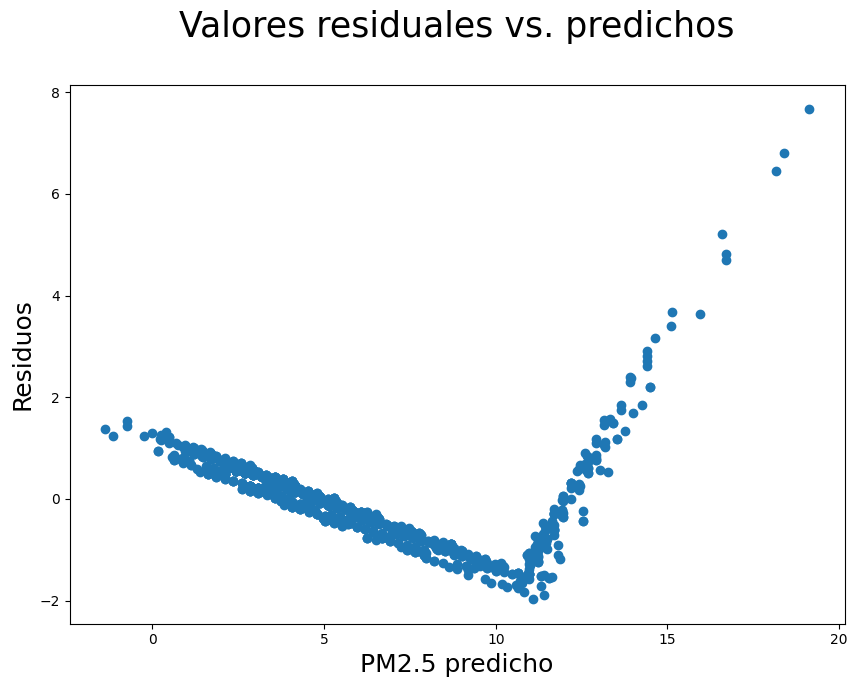

In [35]:
plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos\n",fontsize=25)
plt.xlabel("PM2.5 predicho",fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions,y=y_test-predictions)

# Error cuadrático medio

In [36]:
print(
    "Mean square error (MSE):",
    metrics.mean_squared_error(y_test, predictions)
)

Mean square error (MSE): 0.7661590922639818


# Resumen estadístico del modelo

In [37]:
import statsmodels.api as sm

In [38]:
Xs = sm.add_constant(x)

stat_model = sm.OLS(y, Xs)

stat_result = stat_model.fit()

print(stat_result.summary())

                                  OLS Regression Results                                  
Dep. Variable:     Daily Mean PM2.5 Concentration   R-squared:                       0.920
Model:                                        OLS   Adj. R-squared:                  0.920
Method:                             Least Squares   F-statistic:                 1.095e+04
Date:                            Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                                    21:11:06   Log-Likelihood:                -5573.6
No. Observations:                            3804   AIC:                         1.116e+04
Df Residuals:                                3799   BIC:                         1.119e+04
Df Model:                                       4                                         
Covariance Type:                        nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------